**Neural Network from Scratch: MNIST Digit Classifier**

**Introduction**

Most people learning machine learning jump straight into TensorFlow or PyTorch without understanding what is actually happening under the hood.
In this project I built a fully functioning neural network using only NumPy to deeply understand the mathematics that power modern AI. Every single component was written by hand:

- Forward propagation
- Activation functions (ReLU and Softmax)
- Cross entropy loss
- Backpropagation and the chain rule
- Gradient descent and weight updates

The dataset used is MNIST, the "hello world" of machine learning, containing 70,000 handwritten digit images. The final model achieves 90%+ accuracy on unseen test data.
This is purely self study and preparation for bigger projects. No shortcuts taken.

**Libraries**

This project uses only lightweight, standard libraries. No deep learning frameworks were used intentionally.

- **NumPy**: All matrix operations, math, and data manipulation
- **Matplotlib**: Visualizing images and training curves
- **urllib.request**: Downloading the raw MNIST dataset from the internet
- **gzip**: Decompressing the downloaded dataset files
- **os**: Managing file paths and creating directories

In [1]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import gzip
import os

In [2]:
os.makedirs("datasets", exist_ok= True)

In [3]:
base_url = "https://ossci-datasets.s3.amazonaws.com/mnist/"

files = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images":  "t10k-images-idx3-ubyte.gz",
    "test_labels":  "t10k-labels-idx1-ubyte.gz"
}

In [4]:
for key in files:
    if not os.path.exists(os.path.join("datasets", files[key])):
        print(f"Downloading: {files[key]}")
        urllib.request.urlretrieve(base_url+ files[key], os.path.join("datasets", files[key]))
        print("Done.")
    else:
        print("I already have the necessary data.")

I already have the necessary data.
I already have the necessary data.
I already have the necessary data.
I already have the necessary data.


In [5]:
def parse_images(path):
    with gzip.open(path, 'rb') as f: #opening compresses file in read binary mode
        f.read(16) #skips the first 16 bits
        data = np.frombuffer(f.read(), dtype = np.uint8) #converting to numpy array
    return data.reshape(-1, 784) #-1 decided automatically number of rows



In [6]:
def parse_labels(path):
    with gzip.open(path, 'rb') as f:
        f.read(8) #skips the first 8 bits
        data = np.frombuffer(f.read(), dtype = np.uint8)
    return data

In [7]:
#assign each variable the proper data
X_train = parse_images(os.path.join("datasets", files["train_images"]))
y_train = parse_labels(os.path.join("datasets", files["train_labels"]))
X_test = parse_images(os.path.join("datasets", files["test_images"]))
y_test = parse_labels(os.path.join("datasets", files["test_labels"]))

In [8]:
#verifying each variable
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 784)
(60000,)
(10000, 784)
(10000,)


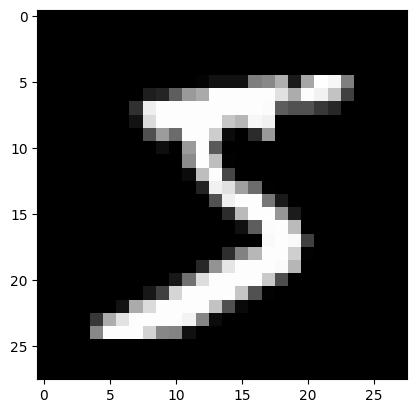

5


In [9]:
#Visualization
plt.imshow(X_train[0].reshape(28, 28), cmap = 'gray')
plt.show()
print(y_train[0])

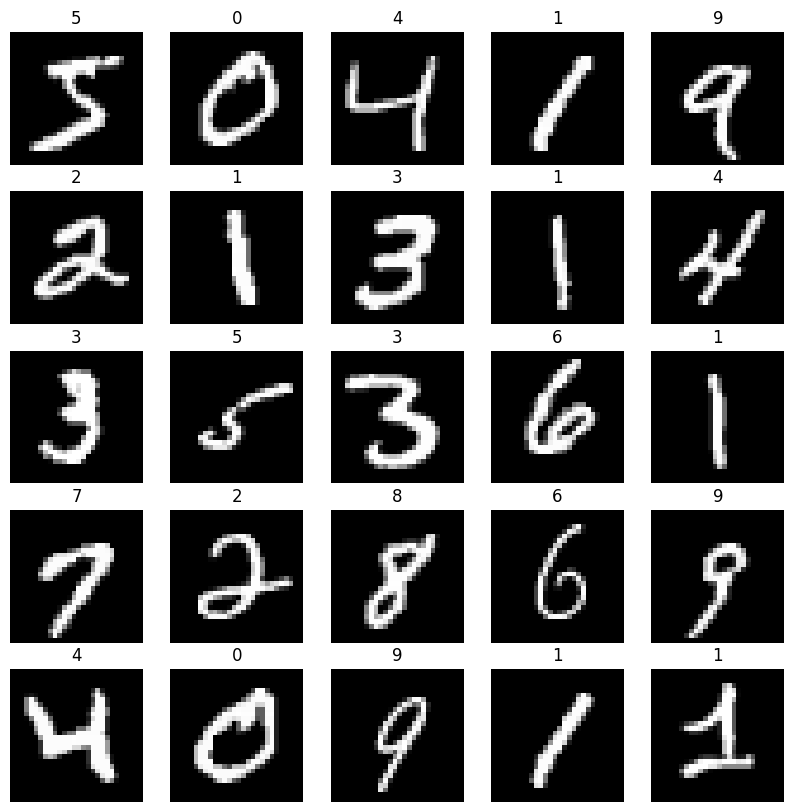

In [31]:
plt.figure(figsize = (10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap = 'gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()
        

In [10]:
#Normalization
X_train = X_train / 255
X_test = X_test / 255

In [11]:
#quick check
print(X_train.max())
print(X_test.max())

1.0
1.0


In [12]:
#neural network start
#initialize network parameters
W1 = np.random.randn(784, 128) * 0.01 #input -> hl (784 inputs and 128 neuron)
b1 = np.zeros(128) #one bias per neuron in the hl
W2 = np.random.randn(128, 10) * 0.01 #hl -> output (128 neurons and 10 outputs) 
b2 = np.zeros(10) #one bias per output neuron

In [13]:
#activation function Relu
def relu(x):
    return np.maximum(0, x)

In [14]:
#activation function softmax
def softmax(x):
    e_x = np.exp(x - np.max(x, axis = 1, keepdims = True)) #mathematical stability  
    return e_x / np.sum(e_x, axis = 1, keepdims = True)

In [15]:
#forward pass
def forward_pass(X, W1, W2, b1, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)
    return A1, A2, Z1

In [16]:
A1, A2, Z1 = forward_pass(X_train, W1, W2, b1, b2)
print(A2.shape)
print(A2[0])

(60000, 10)
[0.0985105  0.09970344 0.09950297 0.10065435 0.10103847 0.09937657
 0.09957901 0.09974819 0.10097808 0.10090842]


In [17]:
#cross entropy loss (evaluate the model)
def cross_entropy_loss(A2, y):
    n = y.shape[0] #number of samples
    loss = np.mean(-np.log(A2[np.arange(n), y])) 
    return loss

In [18]:
loss = cross_entropy_loss(A2, y_train)
print(loss)

2.302764475819571


In [19]:
def backward_pass(X, y, W2, A1, A2, Z1):
    n = y.shape[0]
    #one-hot encode the labels to change the shape
    Y_onehot = np.zeros((n, 10))
    Y_onehot[np.arange(n), y] = 1
    #output layer gradients
    dZ2 = A2 - Y_onehot #error at output layer (predicted - actual)
    dW2 = A1.T @ dZ2 / n #gradient for W2
    db2 = np.mean(dZ2, axis=0) #gradient for b2
    #hidden layer gradients
    dA1 = dZ2 @ W2.T #propagate error back through W2
    dZ1 = dA1 * (Z1 > 0) #apply ReLU derivative
    dW1 = X.T @ dZ1 / n #gradient for W1
    db1 = np.mean(dZ1, axis=0) #gradient for b1

    return dW1, db1, dW2, db2

Note: When we combine the cross entropy loss and softmax activation together and differentiate, a beautiful mathematical cancellation occurs. The derivative of log (from cross entropy) is 1/x, and the derivative of softmax produces terms with A2 * (1 - A2). When multiplied together through the chain rule, these terms cancel each other out, leaving us with the elegant result: dZ2 = A2 - Y_onehot, simply the difference between what the network predicted and the correct answer. This is one of the reasons why cross entropy loss and softmax are almost always used together, they were designed for each other and their combined derivative is simple, stable, and intuitive.

In [21]:
#gradient descent10
def update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 -= learning_rate * dW1 #update input -> hidden layer
    b1 -= learning_rate * db1 #update hiddent layer biases
    W2 -= learning_rate * dW2 #update hidden -> output weights
    b2 -= learning_rate * db2 #update output layer biases

    return W1, b1, W2, b2

In [23]:
#computing accuracy
def accuracy(A2, y):
    predictions = np.argmax(A2, axis=1)  #shape (60000,)
    accuracy = np.mean(predictions == y)
    return accuracy

In [24]:
#training loop

#store values for analysis
train_loss_list = []
test_loss_list = []
train_acc_list = []
test_acc_list = []

learning_rate = 0.1

for i in range(500):
    A1_train, A2_train, Z1_train = forward_pass(X_train, W1, W2, b1, b2) #compute predictions
    A1_test, A2_test, Z1_test = forward_pass(X_test, W1, W2, b1, b2)
    loss_train = cross_entropy_loss(A2_train, y_train) #compute training loss
    train_loss_list.append(loss_train)
    loss_test = cross_entropy_loss(A2_test, y_test) #compute test loss
    test_loss_list.append(loss_test)
    acc_train = accuracy(A2_train, y_train)
    train_acc_list.append(acc_train)
    acc_test = accuracy(A2_test, y_test)
    test_acc_list.append(acc_test)
    print(f"Epoch: {i + 1}/500 | Train Loss: {loss_train:.4f} | Test loss: {loss_test:.4f} | Accuracy Train: {acc_train:.4f} | Accuracy Tets: {acc_test:.4f}")
    dW1, db1, dW2, db2 = backward_pass(X_train, y_train, W2, A1_train, A2_train, Z1_train) #compute gradients
    W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate) #update weights using gradient descent

Epoch: 1/500 | Train Loss: 2.3028 | Test loss: 2.3027 | Accuracy Train: 0.1540 | Accuracy Tets: 0.1585
Epoch: 2/500 | Train Loss: 2.3017 | Test loss: 2.3016 | Accuracy Train: 0.1937 | Accuracy Tets: 0.2000
Epoch: 3/500 | Train Loss: 2.3007 | Test loss: 2.3005 | Accuracy Train: 0.2298 | Accuracy Tets: 0.2347
Epoch: 4/500 | Train Loss: 2.2996 | Test loss: 2.2994 | Accuracy Train: 0.2606 | Accuracy Tets: 0.2661
Epoch: 5/500 | Train Loss: 2.2985 | Test loss: 2.2983 | Accuracy Train: 0.2890 | Accuracy Tets: 0.2969
Epoch: 6/500 | Train Loss: 2.2974 | Test loss: 2.2972 | Accuracy Train: 0.3167 | Accuracy Tets: 0.3297
Epoch: 7/500 | Train Loss: 2.2963 | Test loss: 2.2960 | Accuracy Train: 0.3463 | Accuracy Tets: 0.3621
Epoch: 8/500 | Train Loss: 2.2951 | Test loss: 2.2948 | Accuracy Train: 0.3763 | Accuracy Tets: 0.3934
Epoch: 9/500 | Train Loss: 2.2938 | Test loss: 2.2935 | Accuracy Train: 0.4041 | Accuracy Tets: 0.4232
Epoch: 10/500 | Train Loss: 2.2924 | Test loss: 2.2921 | Accuracy Train: 

In [25]:
#run forward pass in test data and compute accuracy
A1_test, A2_test, Z1_test = forward_pass(X_test, W1, W2, b1, b2)
test_acc = accuracy(A2_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9077


In [26]:
predictions_test = np.argmax(A2_test, axis = 1)

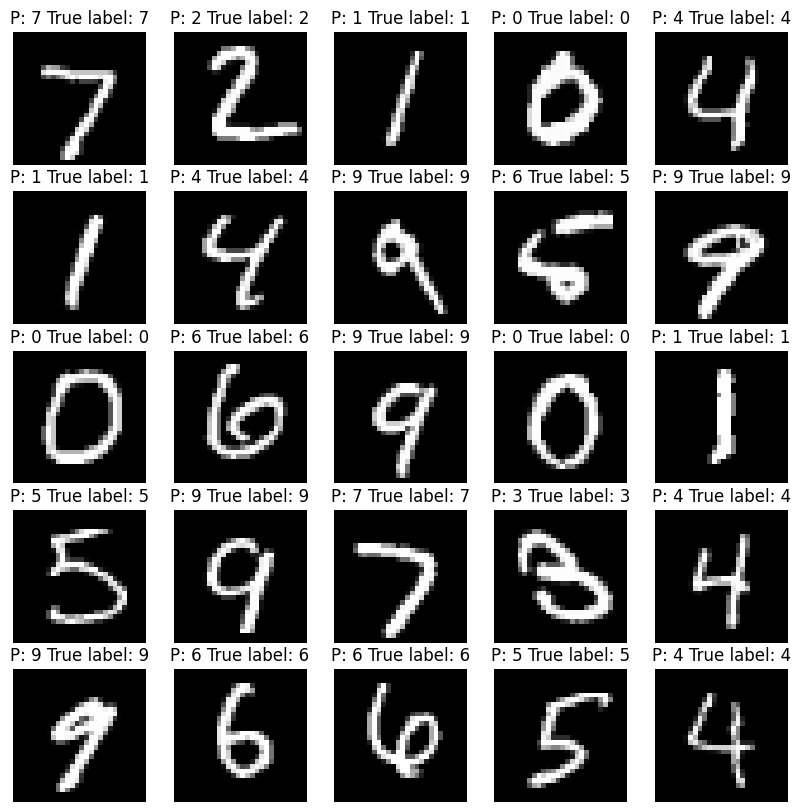

In [27]:
plt.figure(figsize = (10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap = 'gray')
    plt.title(f"P: {predictions_test[i]} True label: {y_test[i]}")
    plt.axis('off')

plt.show()

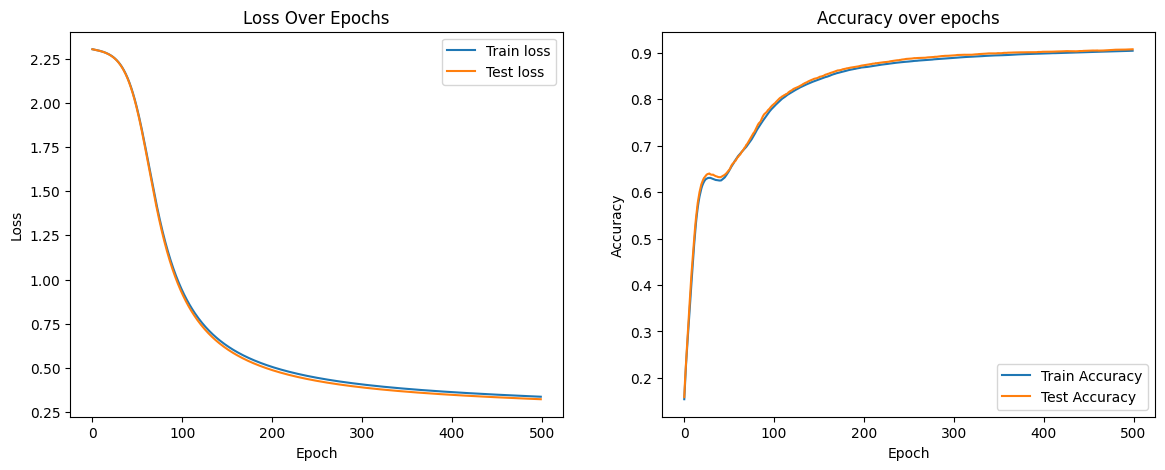

In [28]:
#Visualize training loss vs test loss over epochs
#Visualize training accuracy vs test accuracy over epochs

plt.figure(figsize = (14, 5))

plt.subplot(1, 2, 1)  # 1 row, 2 columns, plot 1
plt.plot(train_loss_list, label = "Train loss")
plt.plot(test_loss_list, label = "Test loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)  # 1 row, 2 columns, plot 2
plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(test_acc_list, label='Test Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()